# Synthetic Control — Basque Terrorism & GDP per Capita

Reads in the region-year panel and confirms the treated unit, donor pool, and time span
ahead of building the synthetic control (Abadie & Gardeazabal 2003).

| | |
|---|---|
| **Treatment** | Onset of ETA terrorist activity (late 1960s/1970s) |
| **Treated unit** | `Basque Country (Pais Vasco)` |
| **Outcome** | `gdpcap` — GDP per capita |
| **Panel** | 18 Spanish regions (incl. national aggregate `Spain (Espana)`), 1955–1997 |
| **Dataset** | Abadie, Diamond & Hainmueller replication data |

In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [153]:
df = pd.read_csv(Path("../data/raw/basque.csv"))

# set the parameters
TREATED_REGION = "Basque Country (Pais Vasco)"
EXCLUDE_UNIT = "Spain (Espana)"  # national aggregate, not a donor region
CONTROL_REGIONS = [region for region in df['regionname'].unique() if region not in [TREATED_REGION, EXCLUDE_UNIT]]
EVENT_START = 1976

print(f"Treated unit  : {TREATED_REGION}")
print(f"Donor regions : {len(CONTROL_REGIONS)}")
print(f"Years         : {df['year'].min():.0f}\u2013{df['year'].max():.0f}")
print(f"Shape         : {df.shape}")


Treated unit  : Basque Country (Pais Vasco)
Donor regions : 16
Years         : 1955–1997
Shape         : (774, 17)


In [154]:
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


regionno                   0
regionname                 0
year                       0
gdpcap                     0
sec.agriculture          684
sec.energy               684
sec.industry             684
sec.construction         684
sec.services.venta       684
sec.services.nonventa    684
school.illit             666
school.prim              666
school.med               666
school.high              666
school.post.high         666
popdens                  756
invest                   198
dtype: int64

## generate the synthetic control

In [155]:
def get_synthetic_control_estimate(df, event_start, treated_region, control_regions, use_scaler=False):
    # pivot once, over the full period — pre-period is later sliced from this
    # rather than re-filtering df, so pre- and full-period matrices share
    # identical column ordering/labels by construction
    control_pivot = df[df['regionname'].isin(control_regions)].pivot_table(
        index='year', columns='regionname', values='gdpcap', aggfunc='mean'
    )
    treated_actual = df[df['regionname'] == treated_region].set_index('year')['gdpcap']

    # weights are estimated on pre-treatment years only, so they reflect how
    # the treated region tracked donors *before* the intervention
    is_preperiod = control_pivot.index < event_start
    preperiod_control = control_pivot.loc[is_preperiod]
    # sliced from treated_actual (not a separate pivot) to guarantee the same
    # year index as preperiod_control, avoiding silent misalignment on .fit()
    preperiod_treatment = treated_actual.loc[is_preperiod].values

    if use_scaler:
        # only X is standardized — y (gdpcap) stays in its original units, so
        # the fitted coefficients/intercept still predict on the original scale
        scaler = StandardScaler().fit(preperiod_control)
        preperiod_control_fit = scaler.transform(preperiod_control)
        control_pivot_fit = scaler.transform(control_pivot)
    else:
        preperiod_control_fit = preperiod_control
        control_pivot_fit = control_pivot

    lasso_model = LassoCV(cv=5, max_iter=10000).fit(preperiod_control_fit, preperiod_treatment)
    # index by the fitted matrix's actual columns, not a separately-built
    # region list — pivot_table sorts columns alphabetically, and a mismatched
    # list here silently mislabels which weight belongs to which region
    lasso_coefficients = pd.Series(lasso_model.coef_, index=preperiod_control.columns)

    # apply pre-period weights across the full timeline to get the
    # counterfactual trajectory for both pre- and post-treatment years
    synthetic_control = pd.Series(
        control_pivot_fit @ lasso_coefficients.values + lasso_model.intercept_,
        index=control_pivot.index,
    )
    # actual minus synthetic: negative gap = treatment lowered the outcome
    treatment_effect = treated_actual - synthetic_control

    # average post-treatment gap = estimated average treatment effect
    postperiod = treatment_effect[treatment_effect.index > event_start]
    ate = postperiod.mean()

    return ate, treatment_effect, treated_actual, synthetic_control

In [156]:
ate, treatment_effect, treated_actual, synthetic_control = get_synthetic_control_estimate(df, EVENT_START, TREATED_REGION, CONTROL_REGIONS)

   unscaled_ate  scaled_ate
0     -0.950975   -1.025945


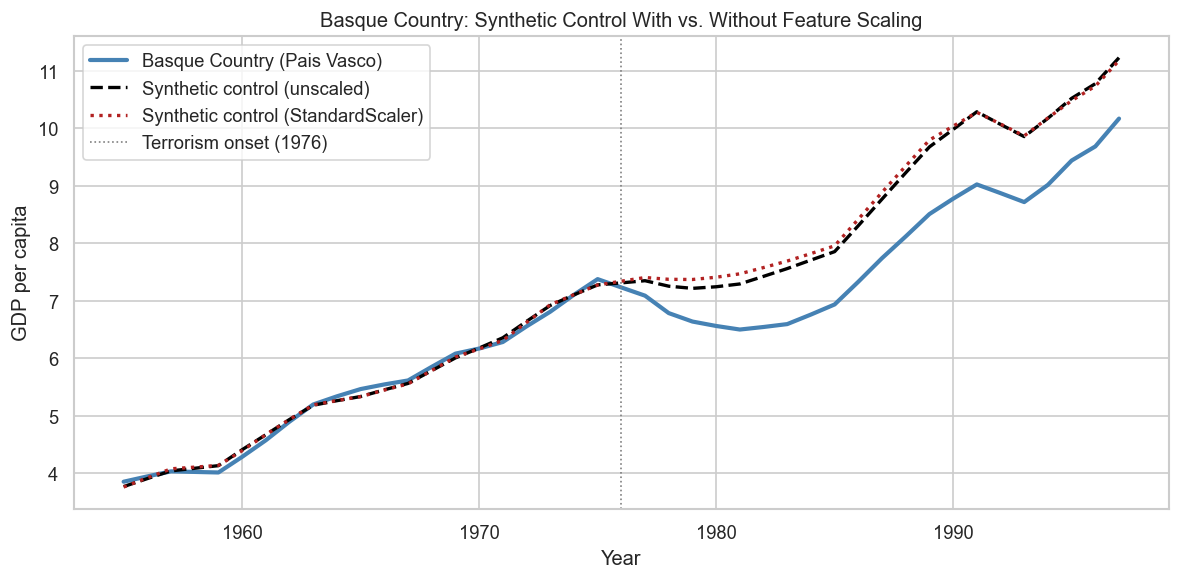

In [157]:
ate_scaled, treatment_effect_scaled, _, synthetic_control_scaled = get_synthetic_control_estimate(
    df, EVENT_START, TREATED_REGION, CONTROL_REGIONS, use_scaler=True
)

lasso_coefficients_compare = pd.DataFrame({
    "unscaled_ate": [ate],
    "scaled_ate": [ate_scaled],
})
print(lasso_coefficients_compare)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(treated_actual.index, treated_actual.values, color="steelblue", linewidth=2.5, label=TREATED_REGION)
ax.plot(synthetic_control.index, synthetic_control.values, color="black", linestyle="--", linewidth=2, label="Synthetic control (unscaled)")
ax.plot(synthetic_control_scaled.index, synthetic_control_scaled.values, color="firebrick", linestyle=":", linewidth=2, label="Synthetic control (StandardScaler)")
ax.axvline(EVENT_START, color="grey", linestyle=":", linewidth=1, label=f"Terrorism onset ({EVENT_START})")

ax.set_xlabel("Year")
ax.set_ylabel("GDP per capita")
ax.set_title("Basque Country: Synthetic Control With vs. Without Feature Scaling")
ax.legend()
plt.tight_layout()
plt.show()

## Sanity check: pre-period Pearson correlation (on differences) vs. Lasso weights

Lasso solves a joint regression across all donors at once, so a donor's weight reflects
its *marginal* contribution after accounting for the others — not how similar it looks
to the treated unit on its own. A pairwise Pearson correlation per donor is a useful
face-validity check, but computed on raw GDP levels it's nearly uninformative here: every
Spanish region shared the same national growth trend, so almost all of them show
correlations above 0.97 regardless of any real economic linkage to the Basque Country.
Differencing each series first (year-over-year change) removes that shared trend and
asks whether donors' *fluctuations* — not just their trajectories — track the treated
unit, which is a much more discriminating comparison against the Lasso ranking.

In [158]:
# rebuild the same pre-treatment matrices used inside get_synthetic_control_estimate,
# independently of the fitted model, so this is a genuine cross-check rather than
# re-displaying numbers already implied by the function's output
control_pivot = df[df['regionname'].isin(CONTROL_REGIONS)].pivot_table(
    index='year', columns='regionname', values='gdpcap', aggfunc='mean'
)
treated_actual_full = df[df['regionname'] == TREATED_REGION].set_index('year')['gdpcap']

is_preperiod = control_pivot.index < EVENT_START
preperiod_control_check = control_pivot.loc[is_preperiod]
preperiod_treatment_check = treated_actual_full.loc[is_preperiod]

lasso_model_check = LassoCV(cv=5, max_iter=10000).fit(preperiod_control_check, preperiod_treatment_check.values)
lasso_weights_check = pd.Series(lasso_model_check.coef_, index=preperiod_control_check.columns)

# correlation on raw levels is dominated by the shared national GDP trend, so
# almost every donor looks highly "correlated" regardless of any real linkage —
# differencing strips the common trend out and asks whether year-to-year
# fluctuations actually move together, a much more discriminating signal
control_diff = preperiod_control_check.diff().dropna()
treated_diff = preperiod_treatment_check.diff().dropna()
pearson_r_diff = control_diff.corrwith(treated_diff)

donor_diagnostics = pd.DataFrame({
    "lasso_weight": lasso_weights_check,
    "pearson_r_diff": pearson_r_diff,
}).sort_values("lasso_weight", ascending=False)

donor_diagnostics

,lasso_weight,pearson_r_diff
regionname,,
Cataluna,0.584994,0.801589
Navarra (Comunidad Foral De),0.385996,0.835606
Andalucia,0.000000,0.510511
Aragon,0.000000,0.816136
Baleares (Islas),0.000000,0.294149
Canarias,0.000000,0.099424
Cantabria,0.000000,0.775138
Castilla Y Leon,0.000000,0.698028
Castilla-La Mancha,0.000000,0.479261


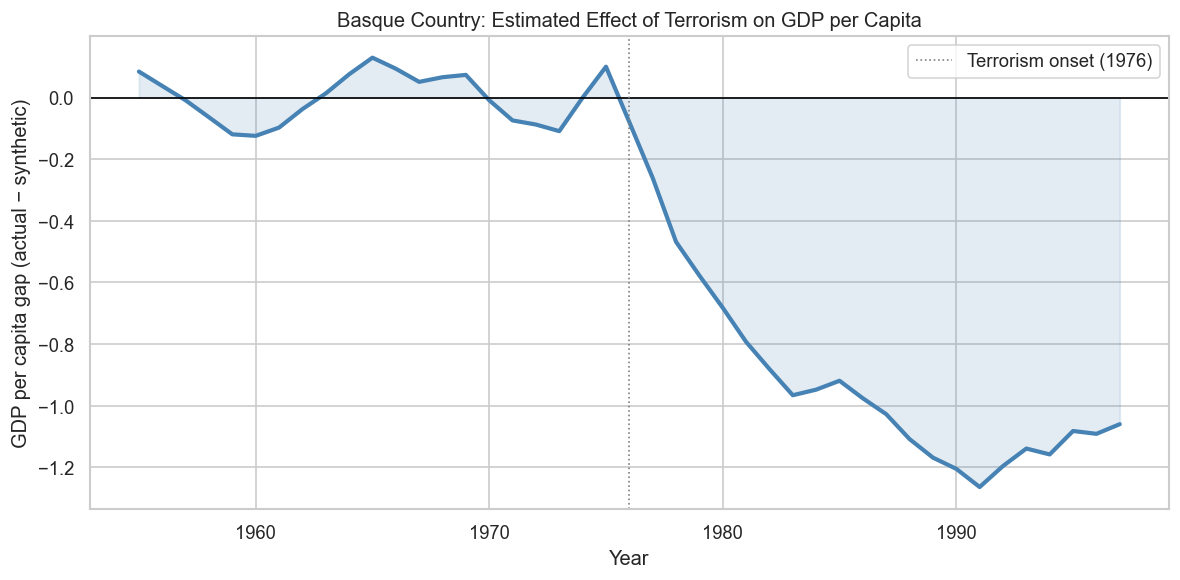

In [159]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(treatment_effect.index, treatment_effect.values, color="steelblue", linewidth=2.5)
ax.axhline(0, color="black", linewidth=1)
ax.axvline(EVENT_START, color="grey", linestyle=":", linewidth=1, label=f"Terrorism onset ({EVENT_START})")
ax.fill_between(treatment_effect.index, treatment_effect.values, 0, color="steelblue", alpha=0.15)

ax.set_xlabel("Year")
ax.set_ylabel("GDP per capita gap (actual − synthetic)")
ax.set_title("Basque Country: Estimated Effect of Terrorism on GDP per Capita")
ax.legend()
plt.tight_layout()
plt.show()


In [160]:
postperiod = treatment_effect[treatment_effect.index > EVENT_START]
synthetic_postperiod_mean = synthetic_control[synthetic_control.index > EVENT_START].mean()

print("Post-treatment period treatment effect: ")
print(round(postperiod.mean(), 3))
print(round(100 * postperiod.mean() / synthetic_postperiod_mean, 1), '%')

Post-treatment period treatment effect: 
-0.951
-10.7 %


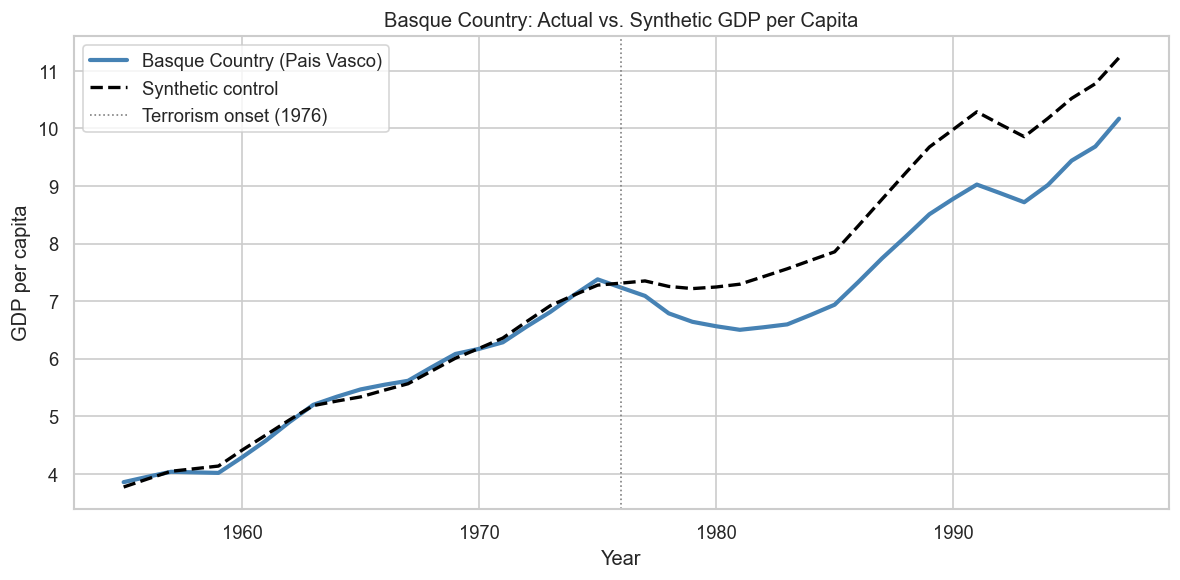

In [161]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(treated_actual.index, treated_actual.values, color="steelblue", linewidth=2.5, label=TREATED_REGION)
ax.plot(synthetic_control.index, synthetic_control.values, color="black", linestyle="--", linewidth=2, label="Synthetic control")
ax.axvline(EVENT_START, color="grey", linestyle=":", linewidth=1, label=f"Terrorism onset ({EVENT_START})")

ax.set_xlabel("Year")
ax.set_ylabel("GDP per capita")
ax.set_title("Basque Country: Actual vs. Synthetic GDP per Capita")
ax.legend()
plt.tight_layout()
plt.show()


## permuation test

In [162]:
# collect the full treatment_effect series (not just the post-period ATE) for
# the treated region and every placebo region, since RMSPE ratios need the
# year-by-year gap over both the pre- and post-treatment windows
region_treatment_effects = {TREATED_REGION: treatment_effect}

placebo_ates = []
for placebo_region in CONTROL_REGIONS:
    placebo_control_regions = [region for region in CONTROL_REGIONS if region != placebo_region]
    placebo_ate, placebo_treatment_effect, _, _ = get_synthetic_control_estimate(
        df, EVENT_START, treated_region=placebo_region, control_regions=placebo_control_regions
    )
    placebo_ates.append(placebo_ate)
    region_treatment_effects[placebo_region] = placebo_treatment_effect
    print(placebo_region, placebo_ate)

Andalucia -0.22705804044156833
Aragon 0.46887935735827907
Principado De Asturias -0.6872801161367843
Baleares (Islas) -0.1904784027185894
Canarias 0.030203328655529618
Cantabria -0.2630869294509335
Castilla Y Leon 0.22397476368212701
Castilla-La Mancha -0.20157398755496833
Cataluna -0.09944509176586523
Comunidad Valenciana 0.22329820045525675
Extremadura 0.520199186719405
Galicia 0.2207624679204446
Madrid (Comunidad De) -0.40929570547157973
Murcia (Region de) -0.2664150577505386
Navarra (Comunidad Foral De) 0.13489116391847697
Rioja (La) 0.6571351366396924


In [170]:
preperiod_rmspe = {}
postperiod_rmspe = {}

for region, series in region_treatment_effects.items():
    preperiod_gap = series[series.index < EVENT_START]
    postperiod_gap = series[series.index > EVENT_START]

    preperiod_rmspe[region] = np.sqrt((preperiod_gap ** 2).mean())
    postperiod_rmspe[region] = np.sqrt((postperiod_gap ** 2).mean())

rmspe_ratio = pd.Series({
    region: postperiod_rmspe[region] / preperiod_rmspe[region]
    for region in region_treatment_effects
}).sort_values(ascending=False)

basque_rank = rmspe_ratio.rank(ascending=False)[TREATED_REGION]
p_value = basque_rank / len(rmspe_ratio)

print(rmspe_ratio)
print(f"\nBasque Country rank: {int(basque_rank)} of {len(rmspe_ratio)}")
print(f"Implied p-value: {p_value:.3f}")


Extremadura                     47.369751
Aragon                          25.819588
Andalucia                       20.483551
Rioja (La)                      20.201823
Principado De Asturias          19.984428
Cantabria                       16.893038
Castilla Y Leon                 14.041749
Basque Country (Pais Vasco)     12.406845
Galicia                         11.792157
Navarra (Comunidad Foral De)     9.355874
Murcia (Region de)               8.778717
Madrid (Comunidad De)            8.184753
Castilla-La Mancha               7.858551
Baleares (Islas)                 7.488161
Comunidad Valenciana             6.505737
Cataluna                         5.255287
Canarias                         2.196123
dtype: float64

Basque Country rank: 8 of 17
Implied p-value: 0.471


In [169]:
np.sqrt((preperiod_gaps['Basque Country (Pais Vasco)']  ** 2).mean())

np.float64(0.07938717713500289)

(array([1., 0., 1., 5., 1., 1., 4., 0., 2., 1.]),
 array([-0.68728012, -0.55283859, -0.41839707, -0.28395554, -0.14951402,
        -0.01507249,  0.11936904,  0.25381056,  0.38825209,  0.52269361,
         0.65713514]),
 <BarContainer object of 10 artists>)

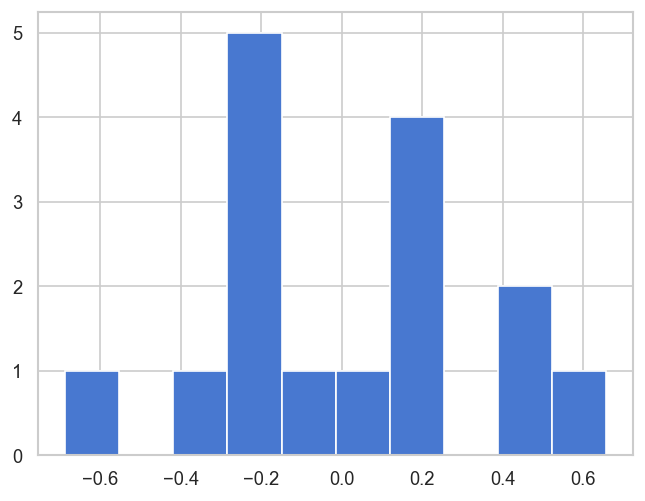

In [163]:
plt.hist(placebo_ates)